In [1]:
import itertools
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

pd.set_option('display.width', 2000)              # increase total line width
pd.set_option('display.expand_frame_repr', False) # disable wrapping into multiple rows

## Pairwise Win Percentage 

In [11]:
def pairwise_win(df,tag):
    models = [c for c in df.columns if c != "seed"]

    win_matrix = pd.DataFrame(index=models, columns=models, dtype=float)

    for m1 in models:
        for m2 in models:
            if m1 == m2:
                win_matrix.loc[m1, m2] = np.nan
            else:
                wins = (df[m1] > df[m2]).sum()
                win_matrix.loc[m1, m2] = 100 * wins / len(df)

    plt.figure(figsize=(10,6))
    sns.heatmap(
        win_matrix,
        annot=True,
        fmt=".0f",
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        linewidths=.5,
        cbar_kws={"label": "Win rate (%)"}
    )

    # Rotate x-axis labels
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.savefig(f"pairwise_win_{tag}_seed.pdf", dpi=300)


In [3]:
seed_train = pd.read_csv("../model_performance/episode_reward_seed_train.csv")
seed_test = pd.read_csv("../model_performance/episode_reward_seed_test.csv")
seed_all = pd.concat([seed_test, seed_train], axis=0)

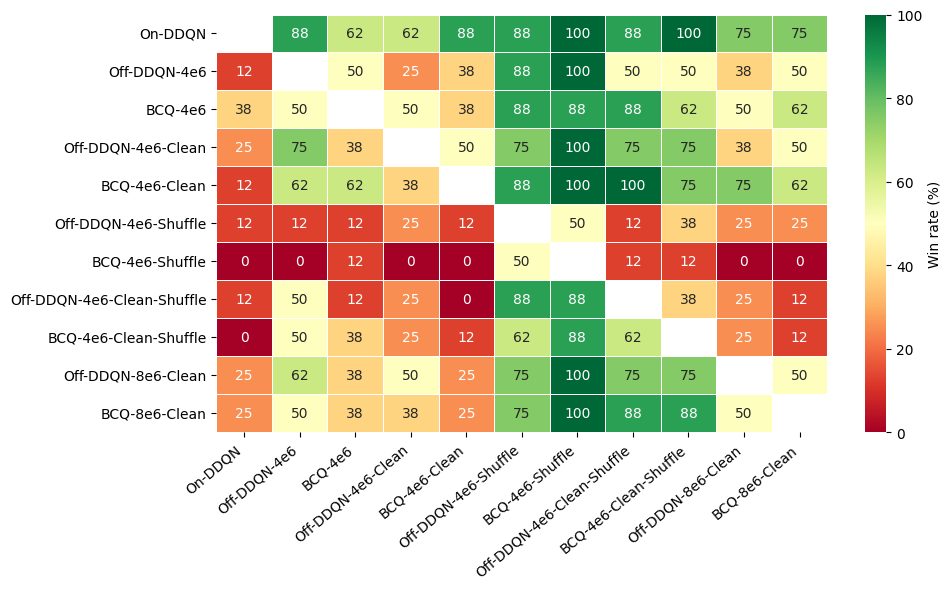

In [13]:
pairwise_win(seed_train, tag="train")

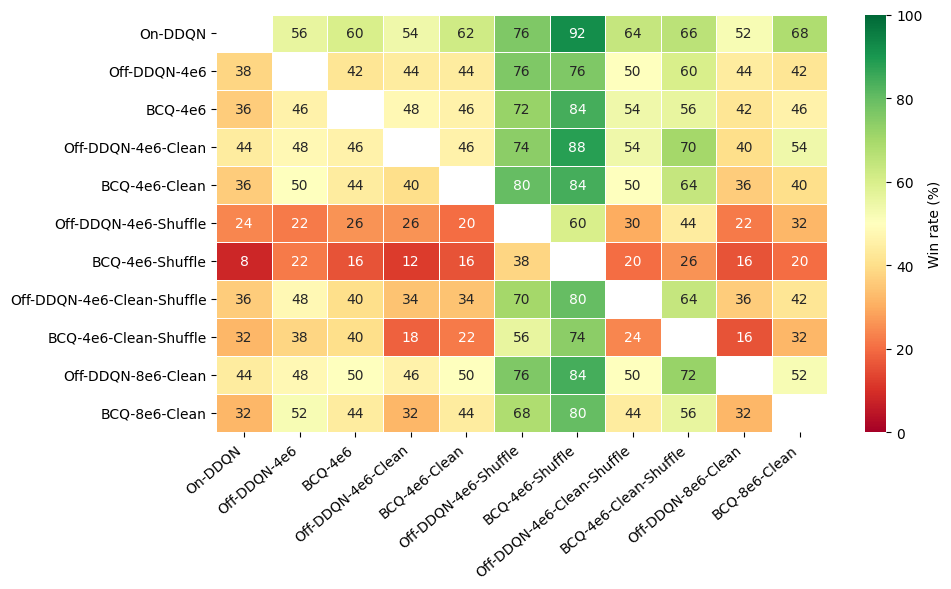

In [14]:
pairwise_win(seed_test, tag="test")

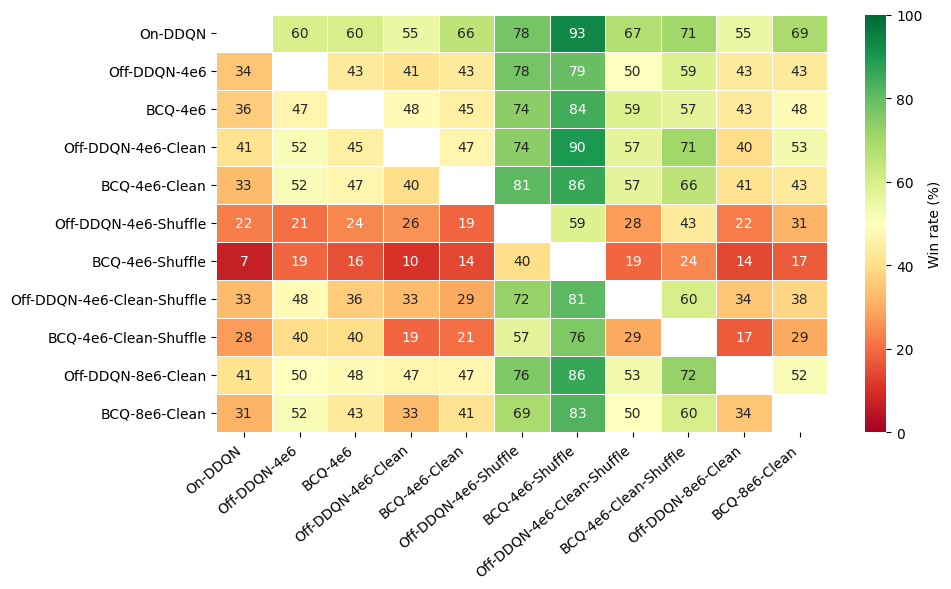

In [15]:
pairwise_win(seed_all, tag="all")

## Overall Win Rate

In [16]:
def overall_win(df, tag):
    models = [c for c in df.columns if c != "seed"]

    overall_win_rate = {}

    n_seeds = len(df)
    n_models = len(models)

    for m1 in models:
        wins = 0

        for m2 in models:
            if m1 == m2:
                continue

            wins += (df[m1] > df[m2]).sum()

        total = (n_models - 1) * n_seeds
        overall_win_rate[m1] = 100 * wins / total

    overall_win_rate = (
        pd.Series(overall_win_rate)
        .sort_values(ascending=False)
    )

    colors = ["#2ca02c" if x >= 50 else "#d62728" for x in overall_win_rate]

    fig, ax = plt.subplots(figsize=(10, 4.5))

    ax.barh(
        overall_win_rate.index,
        overall_win_rate.values,
        color=colors
    )

    ax.set_axisbelow(True)  # sends grid behind everything including the histo

    # Major ticks every 5%
    ax.xaxis.set_major_locator(MultipleLocator(5))

    # Minor ticks every 1%
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    # Grid
    ax.grid(which='major', axis='x', linestyle='--', linewidth=0.8)
    ax.grid(which='minor', axis='x', linestyle=':', linewidth=0.4, alpha=0.5)

    ax.axvline(
        50,
        color='k',
        linestyle='--',
        label='50% (coin flip)'
    )

    # ax.grid(axis='x', linestyle='--', alpha=0.7)

    plt.xlabel("Overall Win Percentage (%)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"Overall_win_{tag}_seed.pdf", dpi=300)

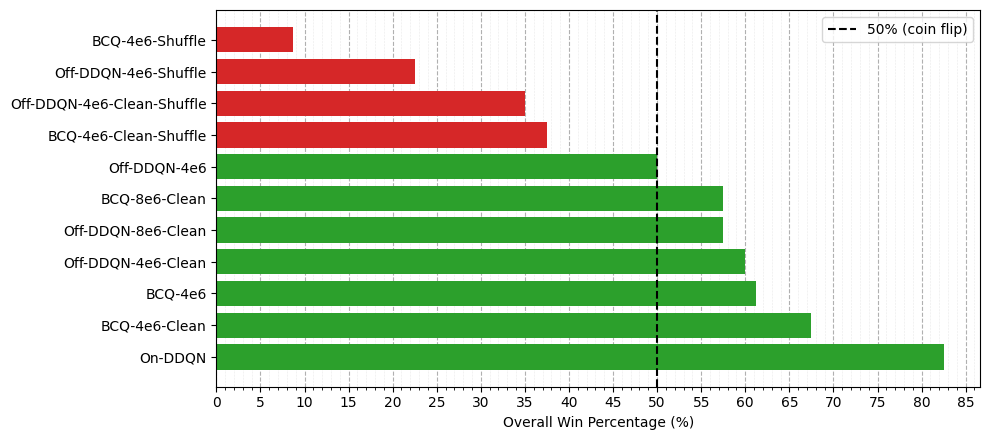

In [17]:
overall_win(seed_train, "train")

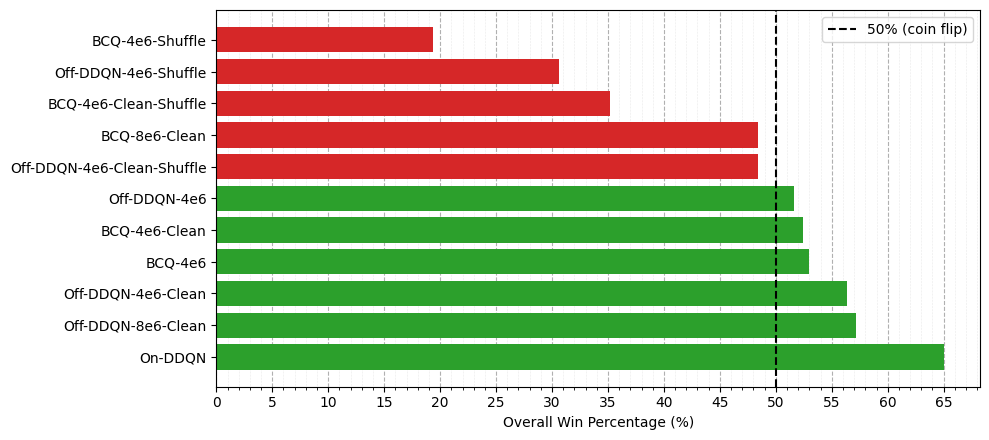

In [18]:
overall_win(seed_test, "test")

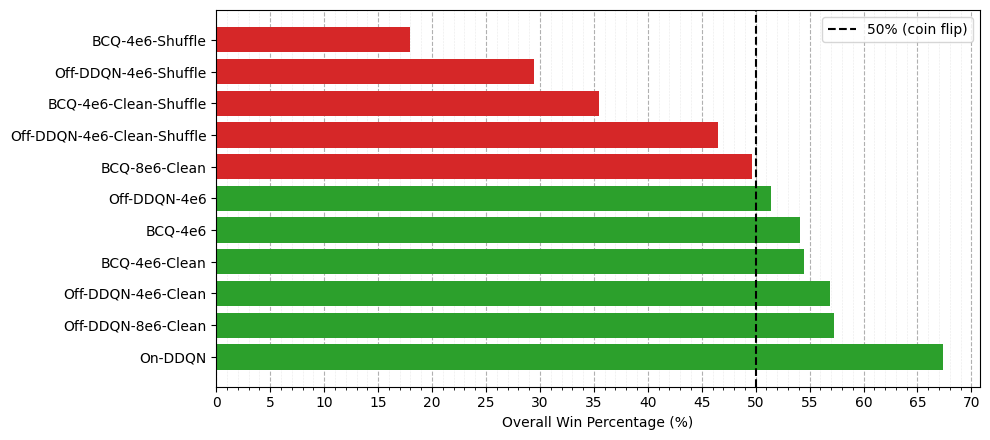

In [19]:
overall_win(seed_all, "all")